# Day 4 Activity 1: Example Solution

This notebook explains the main reliability problems in the current `starter.py` workflow and shows one corrected version.

## Potential Issues In The Starter Code

1. `compute_iou()` does not validate boxes or missing coordinates.
2. `compute_iou()` does not clamp negative overlap widths and heights at zero.
3. `build_agreement_curve()` drops missing IoU values before calculating agreement, which inflates the result.


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def validate_box(box):
    if len(box) != 4:
        raise ValueError("box must contain x1, y1, x2, y2")

    if any(pd.isna(box)):
        raise ValueError("box cannot contain missing coordinates")

    if box[2] <= box[0] or box[3] <= box[1]:
        raise ValueError("box coordinates must satisfy x2 > x1 and y2 > y1")


def compute_iou(box_a, box_b):
    validate_box(box_a)
    validate_box(box_b)

    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    inter_width = max(0, x_right - x_left)
    inter_height = max(0, y_bottom - y_top)
    inter_area = inter_width * inter_height

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union_area = area_a + area_b - inter_area

    if union_area <= 0:
        raise ValueError("union area must be positive")

    return inter_area / union_area


def compute_iou_safe(box_a, box_b):
    try:
        return compute_iou(box_a, box_b)
    except ValueError:
        return np.nan


def add_iou_all_frames(box_pairs):
    box_pairs = box_pairs.copy()

    for idx, row in box_pairs.iterrows():
        box_a = [row["box_a_x1"], row["box_a_y1"], row["box_a_x2"], row["box_a_y2"]]
        box_b = [row["box_b_x1"], row["box_b_y1"], row["box_b_x2"], row["box_b_y2"]]
        box_pairs.loc[idx, "iou"] = compute_iou_safe(box_a, box_b)

    return box_pairs


def build_agreement_curve(box_pairs):
    thresholds = [value / 100 for value in range(0, 101, 5)]
    return pd.DataFrame(
        {
            "iou_threshold": thresholds,
            "percent_agreement": [
                (box_pairs["iou"] >= threshold).mean() * 100 for threshold in thresholds
            ],
        }
    )


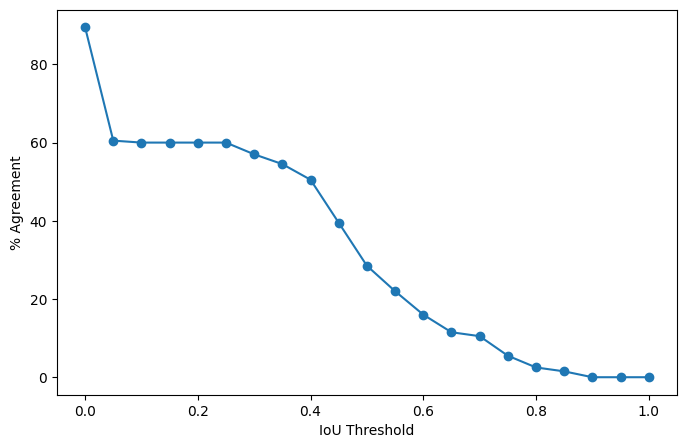

In [5]:
csv_path = Path("modules/day-04-reliable/activities/activity-1/mock_box_pairs.csv")
if not csv_path.exists():
    csv_path = Path("mock_box_pairs.csv")

box_pairs = pd.read_csv(csv_path)
box_pairs_w_iou = add_iou_all_frames(box_pairs)
curve_info = build_agreement_curve(box_pairs_w_iou)

assert (box_pairs_w_iou.loc[box_pairs_w_iou["scenario"] == "touching_edge", "iou"] == 0).all()
assert box_pairs_w_iou["iou"].isna().sum() == 21
assert box_pairs_w_iou.loc[box_pairs_w_iou["scenario"] == "invalid_box", "iou"].isna().sum() == 20
assert box_pairs_w_iou.loc[box_pairs_w_iou["scenario"] == "no_overlap", "iou"].isna().sum() == 1
assert (box_pairs_w_iou.loc[box_pairs_w_iou["scenario"] == "normal_overlap", "iou"] > 0).all()
assert curve_info.loc[curve_info["iou_threshold"] == 0, "percent_agreement"].iat[0] == 89.5

plt.figure(figsize=(8, 5))
plt.plot(curve_info["iou_threshold"], curve_info["percent_agreement"])
plt.scatter(curve_info["iou_threshold"], curve_info["percent_agreement"])
plt.xlabel("IoU Threshold")
plt.ylabel("% Agreement")
plt.show()
